In [14]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]   # move up from notebooks/
sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, matthews_corrcoef, average_precision_score
from pathlib import Path
from proteins.data.datasets import ESMCSingleDS
from proteins.models.model import SequenceActiveSiteHead
import torch
from proteins.data.utils import bucket_collate_fn
from torch.utils.data import Subset, DataLoader
import numpy as np
from proteins.training.losses import BinaryFocalLoss
from sklearn.model_selection import GroupShuffleSplit
from proteins.testing.model_test import Tester


In [15]:
def analyze_val_data(path):
    data = np.load(path)
    data = {f: data[f] for f in data.files}
    mcc = np.array([matthews_corrcoef(data['labels'][i], data['logits'][i]>0.5) for i in range(len(data['logits']))])
    f1 = np.array([f1_score(data['labels'][i], data['logits'][i]>0.5) for i in range(len(data['logits']))])
    prc = np.array([average_precision_score(data['labels'][i], data['logits'][i]) for i in range(len(data['logits']))])
    return data, prc, f1, mcc

def plot_data(data, prc, f1, mcc, epoch=-1):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    ax=axes[0]
    ax.plot(mcc, label='MCC')
    ax.plot(f1, label='F1')
    ax.plot(prc, label='PRC')
    ax.legend()

    ax=axes[1]
    if isinstance(epoch, list):
        red = plt.cm.Reds
        green = plt.cm.Greens
        reds = red(np.linspace(0.25, 0.9, len(epoch)))
        greens = green(np.linspace(0.25, 0.9, len(epoch)))
        for e, r, g in zip(epoch, reds, greens):
            sns.kdeplot(data['logits'][e][data['labels'][e] == 0], fill=True, color=r, label=f'Non-Binding{e}', ax=ax)
            sns.kdeplot(data['logits'][e][data['labels'][e] == 1], fill=True, color=g, label=f'Binding{e}', ax=ax)
    else:
        sns.kdeplot(data['logits'][epoch][data['labels'][epoch] == 0], fill=True, color='red', label='Non-Binding', ax=ax)
        sns.kdeplot(data['logits'][epoch][data['labels'][epoch] == 1], fill=True, color='green', label='Binding', ax=ax)
    ax.set_title(f'Logit Separation')
    ax.set_xlabel('Logits')
    ax.legend()

data = analyze_val_data('/Users/connorott/Downloads/trial_0003/val_metrics.npz')

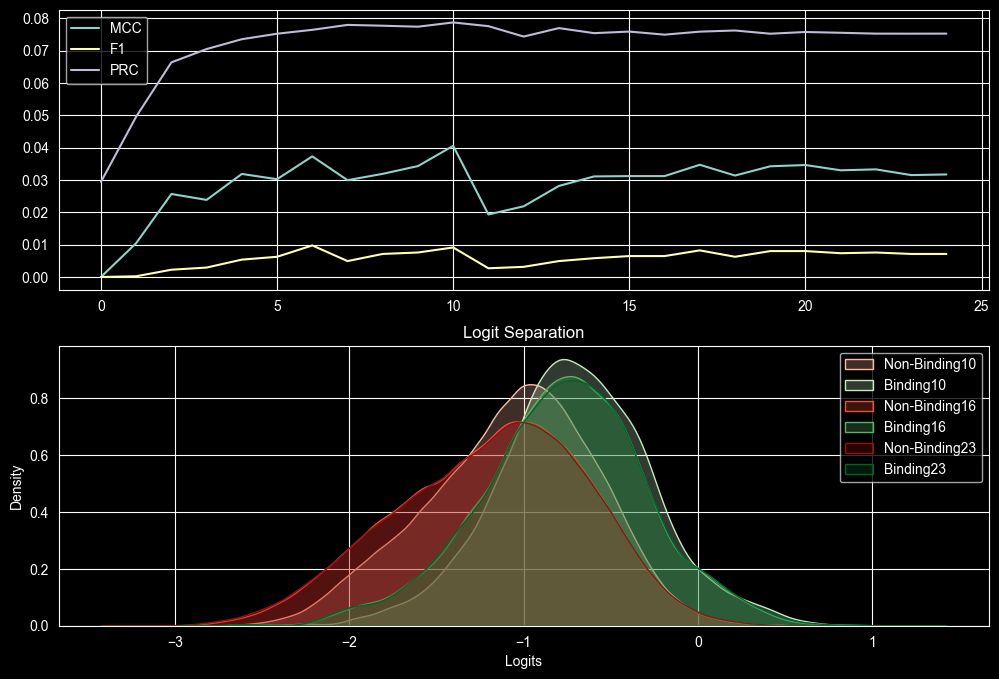

In [21]:

plot_data(*data, epoch=[10, 16, 23])

In [ ]:
data_name = 'IEDB_Jespersen'
model_name = 'esmc_300m'
base_data_dir = Path.cwd() / 'data' / 'data_files'
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')
dataset=ESMCSingleDS(data_name, model_name, save_dir=base_data_dir)
cv_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
cv_splits = next(cv_splitter.split(dataset.data, groups=dataset.get_data_groups()))
val_ds = Subset(dataset, cv_splits[-1])

tester = Tester(SequenceActiveSiteHead, val_ds, Path('/Users/connorott/Downloads/trial_0003'), BinaryFocalLoss(reduction='none'))




